# Building an LLM: my ML learning journal

[Open in Colab](https://colab.research.google.com/github/jooonkim/ml/blob/main/ML.ipynb) · [Read the website](https://jooonkim.github.io/ml/)

My notes, code, questions, and experiments in one place. Historical entries retain their original dates and wording.

**Next:** Continue the LLM coursework. Add a new topic at the end using a text cell with `## Topic`.

Executable examples below run on CPU. Incomplete examples are displayed as illustrative snippets.

## Topics

- [ML foundations and learning habits](#ml-foundations-and-learning-habits)
- [A mental map of ML and its mathematics](#a-mental-map-of-ml-and-its-mathematics)
- [Implementing a perceptron from scratch](#implementing-a-perceptron-from-scratch)
- [Exploring local language models](#exploring-local-language-models)
- [Visualizing the Iris dataset](#visualizing-the-iris-dataset)
- [Perceptron convergence and decision boundaries](#perceptron-convergence-and-decision-boundaries)
- [Adaline and linear activation](#adaline-and-linear-activation)
- [Understanding gradient descent](#understanding-gradient-descent)
- [Gradient descent and Adaline](#gradient-descent-and-adaline)
- [Adaline implementation, line by line](#adaline-implementation-line-by-line)
- [Classification with scikit-learn](#classification-with-scikit-learn)
- [Python essentials for ML](#python-essentials-for-ml)
- [Planning a customer churn project](#planning-a-customer-churn-project)
- [Bias, variance, and regularization](#bias-variance-and-regularization)
- [Linear regression and gradient descent](#linear-regression-and-gradient-descent)
- [Logistic regression and the sigmoid function](#logistic-regression-and-the-sigmoid-function)

## My daily study workflow

This journal follows [Sebastian Raschka’s five-stage method for technical books](https://sebastianraschka.com/blog/2025/reading-books.html).

### The five stages

1. **First read — 20 minutes, offline.** Get the big picture. Do not code or search yet; mark confusing ideas.
2. **Second read — code.** Open the matching course notebook in Colab. Type and run the important code yourself.
3. **Exercise.** Attempt one exercise before checking the solution.
4. **Review.** Revisit highlights, resolve the questions that still matter, and write the useful explanation here.
5. **Use it.** Change one thing or apply the idea to a small experiment.

### One-session checklist

```text
[ ] Read without coding
[ ] Re-type and run one small code section
[ ] Try one exercise or change one variable
[ ] Write what I learned / what is unclear / what I will try next
[ ] Save this notebook to GitHub
```

A chapter can take several sessions. Easy material can be skimmed; difficult material deserves another pass. The goal of each session is one clear takeaway and one concrete next step.


## ML foundations and learning habits

*Originally written 2025-11-14.*

Three main types of ML.

- **Supervised Learning, Unsupervised Learning, Reinforcement Learning**
- **Supervised Learning**: Think of this as an approximation problem. Simplest way to distinguish the two types of Supervised Learning: *Classification* is a problem of *discrete variables*, *Regression* is a problem of *continuous variables*.
- **Unsupervised Learning**: Think of this as an extracting meaning problem. Given unlabeled data, what kinds of meaningful information can we extract without the guidance of a known outcome variable or measure of success? 
- **Reinforcement Learning**: This is basically supervised learning, but the feedback is not the correct ground truth. Rather, the feedback is a measure against a reward function. Central question: How do you maximize the (sometimes immediate, sometimes delayed) reward?
- Unsupervised Learning has some interesting subfields. One is **clustering** which can be called **unsupervised classification**, and another is **dimensionality reduction** which can be helpful in preprocessing to remove noise from data.

### Math Notation
- **Features** are $x$ - think of this as variables, inputs, predictors, dimensions, etc.
- **Targets** are $y$ - think of this as outcome, response variable, dependent variable, output, etc.
- **Training Examples** are samples, instances, observations, etc. I prefer training example over sample because samples can also be used to refer to a collection of training examples.
- Superscript $i$ refers to the $i$th training example, and subscript $j$ refers to the $j$th feature. Superscript on top, subscript on the bottom $x^i_j$
- Vectors are $x \in \mathbb{R}^{n \times 1}$ and Matrices are $X \in \mathbb{R}^{n \times m}$
- $x_{ij}$ and $x^i_j$ are both valid ways of writing the $j$th feature of the $i$th training example
- You can think of every feature as an $i$-dimensional column vector $X^i \in \mathbb{R}^{i \times 1}$ (basically, think of a vertical vector)

Cross-Validation: The Answer to the Training vs. Testing vs. Validation problem

- It makes sense to randomly divide a dataset into a training dataset and a testing dataset - you want to use the training data to train the model, and you want to use the testing dataset to evaluate the final model without any biases.
- However, we only know that the model performs well on the test data - we need to further validate it on real-world data (a validation dataset). 
- **Cross-Validation** allows us to further divide a datset into training and validation datasets to *estimate the generalization performance of a model*.

### Personal Notes
- Sebastian Raschka's [tweet](https://x.com/rasbt/status/1988626642990719440) (preserved below) is an incredible framework for how to read technical textbooks. When reading *How to Read a Book* by Mortimer J. Adler, I learned that non-fiction books and fiction books must be read in a different fashion. I now understand that technical books require a third approach. Too often, I find myself in "tutorial hell" where I take extensive notes on the first 1-2 chapters of any one book, and flit around from book to book. I also find that extensive notes in the beginning runs the risk of "missing the forest for the trees" with understanding what concepts are most important.
- I find Raschka's writing style most compelling, so I will use [Machine Learning with PyTorch and Scikit-Learn](https://www.amazon.com/Machine-Learning-PyTorch-Scikit-Learn-learning/dp/1801819319) as my daily driver. I'm supplementing this with Tom Mitchell's classic ML textbook (from the 1990s, but required by my course) and the Hands-On ML textbook by Aurélien Géron (there's a newer PyTorch version of this book, but I'm finding it... hard to acquire).
- I understand that the most important part is not the qualitative note-taking, but the exercises and coding and deliberately breaking things. This is a difficult habit. I found it hard to get into Karpathy's Zero to Hero and Jeremy Howard's Fast AI courses for this reason. I hope that Raschka's tweet will be a good framework.
- My current study plan is measured by input rather than output - I am trying to hold myself accountable to 14 hours of input / week. I'm not measuring output at this stage because I'd like to allow myself random restarts (see the [hill climbing](https://en.wikipedia.org/wiki/Hill_climbing) problem). I am, however, forcing myself to continue to invest quality hours in a simple, measureable format.
- I really enjoyed watching these YouTube videos: [Transformer Neural Networks by StatQuest](https://youtu.be/zxQyTK8quyY?si=mLBPJoS2eSLX4OiJ) and [AI Engineering in 76 Minutes by Marina Wyss](https://www.youtube.com/watch?v=JV3pL1_mn2M&).

### Questions I still have
- My grasp of the concept of unsupervised learning is admittedly still shakey. How do we know when we're not grasping in the dark for a pattern that's not there? Is this harder or easier than a typical SL or RL problem? 
- My understanding of the ML that everyone finds most exciting right now is ML -> DL -> Transformer Architectures -> LLMs. What is the correct way to approach this topic?
- Math... as a former Math major I find it embarrassing how much Calculus/Lin Alg/Probability I have forgotten. I'd love to refresh but would also love to understand exactly what concepts are most required first. I'm resisting the urge to start Calculus 101 all over again so that I can apply Andrej Karpathy's [mantra](https://x.com/karpathy/status/1325154823856033793?lang=en) of "learning on demand."
- Importantly... parameters for techniques like **feature scaling** and **dimensionality reduction** are solely obtained from the training dataset... what does it mean that the performance measured on the test data is overly optimistic?

### Tomorrow's plan
- Continue to read through Raschka.

Addendum: Raschka's [Tweet](https://x.com/rasbt/status/1988626642990719440)

"I often get questions from readers about how to read and get the most out of my book(s) on building LLMs from scratch. My advice is usually based on how I read technical books myself. This is not a one-size-fits-all approach, but I thought it may be useful to share:

1. Read the chapter preferably offline, away from the computer. Either classic physical form or at least on digital devices without internet. This really helps with focus time and minimizing distractions while reading. Highlighting or annotating confusing or interesting things is good, but I would not look things up at this stage. I also wouldn't run code at this stage. At least not yet.

2. On the second read-through, type up and run the code from the chapter. Copying code is tempting because retyping is a lot of work, but it usually helps me to think about the code a bit more (versus just glancing over it). If I get different results than in the book, I would check the book's GitHub repo and try the code from there. If I still get different results, I would try to see if it's due to different package versions, random seeds, CPU/CUDA, etc. If I then still can't find it out, asking the author would not be a bad idea (via book forum, public GitHub repo issues or discussions, and as a last resort, email)

3. After the second read-through and retyping the code, it's usually a good time to try the exercises to solidify my understanding. To check whether I actually understand the content and can work with it independently.

4. Go through the highlights and annotations. I would bookmark important learnings or takeaways, if relevant for a given project, in my notes documents. Often, I also look up additional references to read more about a topic of interest. Also, if I still have any questions that I feel are unanswered after my previous readthroughs and exercises, I would do an online search to find out more.

5. The previous steps were all about soaking up knowledge. Eventually, though, I somehow want to use that knowledge. So I think about which projects would benefit from what I've learned and incorporate it into them. This could involve using the main concept from the chapter, but also sometimes minor tidbits I learned along the way, e.g., even trivial things like whether it actually makes a difference in my project to explicitly call `torch.mps.manual_seed(seed)` instead of just `torch.manual_seed(seed)`.

Of course, none of the above is set in stone. If the topic is overall very familiar or easy, and I am primarily reading the book to get some information in later chapters, skimming a chapter is ok (to not waste my time).

Anyway, I hope this is useful. And happy reading and learning!"


## A mental map of ML and its mathematics

*Originally written 2025-11-15.*

A Mental Map for ML

- Machine Learning: Broad umbrella
- Deep Learning: Subset of ML using multi-layer neural networks
- Transformer architectures: Specific type of neural network architecture introduced in *Attention Is All You Need (Vaswani et al., 2017).*
- LLMs: a large transformer architecture, using a large corpus of text.

The importance of Linear Algebra

- Linear Algebra is the language of ML because ML is fundamentally the art of taking something (image, soundwave, text, etc.), representing it as a **vector** (or matrix), and creating a model that transforms that vector into another vector.
- As an example, for a neural network layer, $y = Wx + b$ represents $y$ the output vector, $W$ the learned weights (as a matrix), $x$ the input vector,  and $b$ the bias vector.
- Linear Algebra permits us not only a compact representation, but also a language to reason about and manipulate these representations.

The importance of Probability

- The guiding principle here is that some branches of computer science deal with entities that are **deterministic** and certain, but ML deals with entities that are **stochastic** (nondeterministic) and uncertain.
- Probability is how you reason in the presence of uncertainty. Interestingly, uncertainty is more common than we think... how many propositions are guaranteed to be true, or events are guaranteed to occur?
- Three possibile sources of uncertainty according to [Goodfellow](https://www.deeplearningbook.org):
    - Inherent stochasticity in the system being modeled
    - Incomplete observability: Even in a deterministic system, can't observe all the variables that drive behavior (e.g., Monty Hall problem)
    - Incomplete modeling: This one is the most interesting. *A model must sometimes discard observed information.* Sometimes, it's more practical to use a simple & uncertain rule than a complex & certain & deterministic rule (e.g., "most birds fly" is better than "birds fly, except..."). It's hard to develop, communicate, maintain, and make it resilient against failure.

### Miscellaneous
- Surprisingly, according to ChatGPT as an answer to one of my questions yesterday, **Reinforcement Learning** is typically "harder" than **Unsupervised Learning**.
    - **Supervised Learning** is the "easiest" because you have clear labels, a clear objective, and a clear way of measuring success (goal: minimize loss).
    - **Unsupervised Learning** is "conceptually tricky, computationally easy." Yes, there's no objective ground truth, but optimization is "stable" (i.e., the loss function is well-behaved, gradient descent makes progress reliably, feedback is consistent). Examples: PCA, k-means, etc.
    - **Reinforcement Learning** is hard because the environment is stochastic, the feedback is often delayed/sparse, and the optimization is unstable.
- To answer another question from yesterday, here is the meaning of "“If you compute parameters for feature scaling or dimensionality reduction using all the data (train + test), the test performance becomes overly optimistic.": your model has seen structures of the test data before evaluation, which means that there was **leakage**. The test set is supposed to simulate new, unseen, real-world data, and so it underestimates the "true error" that the model would have.

Rendering Python using Quarto...


In [1]:
import numpy as np 

x = np.arange(5)
x


Out[1]: array([0, 1, 2, 3, 4])


### Personal Notes
I finally learned the differences between `pip`, Anaconda, and Miniconda today. 

- `pip` is a lightweight universal package installer that can install python libraries (e.g., `numpy`) pretty much anywhere. It only installs packages from PyPI.
- Anaconda is a (huge... 3-5 GB) Python distribution + environment manager - it bundles everything (`pip`, pre-compiled scientific packages, etc.) in one. Its scope goes beyond PyPI.
- Miniconda is a lighter version of Anaconda. It has the environment management that `pip` doesn't have by default, and Python, but nothing else out the gate. This is important because you can manage your own Python versions in isolated environments.
- *Recommendation*: Use Miniconda for environment management + Python version control, use `pip` within each conda environment for packages.
- I created an environment using miniconda called `pyml` with the following packages: NumPy 1.21.2 SciPy 1.7.0 Scikit-learn 1.0 Matplotlib 3.4.3 pandas 1.3.2 python 3.9

A "Karpathy-style" learning math on demand roadmap

- Note: Linear Algebra, followed by Probability, followed by Calculus are the most important

1. Start with a tiny ML/DL problem first (e.g., train a linear classifier or a 2-layer neural net)
You will immediately run into the following math concepts that need refreshing:

- gradients → calc
- matrix multiplies → Lin Alg
- loss functions → probability + info theory
- optimization steps → calc + LA
- embeddings → SVD intuition

2. When you start reading transformers papers, refresh only:

- dot products
- matrix multiplications
- softmax derivatives
- eigen decomposition (for understanding attention as soft nearest-neighbor search)
- probability for next-token prediction

3. When you study self-supervised methods, refresh only:

- KL divergence
- cross-entropy
- covariance
- Gaussians
- contrastive loss geometry

4. When you start fine-tuning LLMs, refresh only:

- gradients of logits
- Jacobians
- basic linear algebra on embeddings
- matrix factorization intuition

### Questions I still have
- N/A as of now

### Tomorrow's plan
- Actually implement something


## Implementing a perceptron from scratch

*Originally written 2025-11-16.*

Implementing the perceptron as a simple ML classification algorithm without scikit-learn

- **Mc-Culloch-Pitts (MCP) neuron model**: The biological neuron as a simple logic gate with multiple input signals arriving at the dendrites and a binary output.
- **Perceptron learning rule**: Frank Rosenblatt built upon this MCP neuron model by proposing an algorithm that would *learn* a weight vector $w$ that would be multiplied with the input features $x$ to make a decision about whether the neuron fires or not: i.e., a binary output.
- This is helpful because it can predict with the classification problem: does a new data point belong to one class or another?

Formally, a decision function $f(z)$ where, given a defined threshold $\theta$:

$z = w_1x_1 + w_2x_2 + ... + w_nx_n = w^Tx$

> **Note**
>
> $w$ and $z$ are both column vectors, which is why we take the **transpose** $w^T$ to get the **dot product** of the $(n \times 1)$ column vectors. $(1 \times n) * (n \times 1) = 1 \times 1$
$f(z) = \begin{cases} 1, & z \ge \theta \\ 0, & z < \theta \end{cases}$

If we introduce a **bias unit** $b = -\theta$ for ease of implementation, then:

$z = w^Tx$ or $z = w_1x_1 + w_2x_2 + ... + w_nx_n + b = w^Tx + b$

$y = f(z) = \begin{cases} 1, & z \ge 0 \\ 0, & z < 0 \end{cases}$

The **perceptron learning rule** can be summarized as follows:

1. Initialize the weights and bias unit to 0
2. For each training example $x^{(i)}$, compute the output value $\hat{y}^{(i)}$ which is the **predicted class label** of the $i$th training example, predicted by the **threshold function** $f(z)$
3. Compare the **predicted class label** of the $i$th training example $\hat{y}^{(i)}$ to the **true class label** of the $i$th training example $y^{(i)}$
4. Update the weights $w$ and bias unit $b$ simultaneously

Formally,

$\forall w_j \in w, w_j := w_j + \Delta w_j$

$\Delta w_j = \eta(y^{(i)} - \hat{y}^{(i)})* x^{(i)}$

$b := b + \Delta b$

$\Delta b = \eta(y^{(i)} - \hat{y}^{(i)})$

> **Note**
>
> $:=$ is "defined as"
> 
> $\eta$ is the Greek letter "eta" and is often used for the **learning rate** in ML, typically defined as a constant between 0 & 1
Some observations:

- Each weight $w_j$ corresponds to a feature $x_j$. The bias unit $b$ does not.
- Each weight update $\Delta w_j$ is proportional to the value of $x^{(i)}_j$. The bias unit update is not. 
    - Compare $x^{(i)}_j = 10$ to $x^{(i)}_j = 1$ in the example where it is incorrectly classified as class $0$ when the true class label is $1$. Assume $\eta = 1$
        - $\Delta w_j = (1 - 0) * 10 = 10$
        - $\Delta w_j = (1 - 0) * 1 = 1$
    - The first example will push the decision boundary by a factor of $10$
- The bias unit $b$ is part of the linear combination (the score that the perceptron computes), not the activation (the **step function**). So, $y = f(z)$ is correct, not $y = f(z) + b$. The bias shifts the **decision boundary**. 
- You can see from the formal definition that the bias unit and weights remain unchanged when the perceptron predicts the class label correctly. *The perceptron only updates when it makes a mistake in classification.*
- If the data is **linearly separable**, the perceptron is guaranteed to find a **separating hyperplane** within a finite amount of updates. If not **linearly separable**, it will update forever - you need to maximum number of **epochs** in this situation.

> **Note**
>
> A **step function** (in the context of perceptrons) is an activation function that outputs only two possible values. It decides yes/no based on whether the input crosses a threshold.
> 
> An **activation function** is applied to a neuron to determine whether it should "fire" or stay inactive.
> 
> An **epoch** is a pass over the training dataset.
Implementation in Python

- If you define the perceptron interface as a Python class, you can initialize new `Perceptron` objects that can learn from data using a `fit` method and make predictions using a `predict` method.

> **Note**
>
> An underscore _ is appended to attributes that are not created upon initialization of object, e.g., `self.w_` 
> 
> In Python's OOP framework, a **class** is the blueprint, an **object** is an instance of the class, `__init__` is the **initializer** method. An **instance method** is a function defined inside a class that operates on a specific instance (object) of that class.
> 
> Every instance method must take `self` as the first parameter because you need to explicitly state which object you are applying it to, i.e., `self.something` means apply this `something` to *this* object so it **persists**. Persistence is important because after the method finishes, the object will still "remember" it (you're attaching it to the object itself and can run `print(object.something)` on it after the method finishes).
> 
> Standard practice for any model class: set hyperparameters as **instance attributes** once on creation under `__init__`, then reuse them whenever you train or retrain the model.


In [2]:
import numpy as np 

class Perceptron:
    """Perceptron classifier.

    Parameters

    eta: float, learning rate between 0.0 and 1.0
    n_iter: int, epochs
    random_state: int, random number generator (RNG) for random weight initialization

    Attributes

    w_: 1d-array, weights after fitting
    b_: scalar, bias unit after fitting
    errors_: list, number of misclassifications aka updates in each epoch
    """

    def __init__(self, eta=0.01, n_iter = 20, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters 

        X: array, features
        y: array, target values

        Returns

        self: object
        """
        rgen = np.random.RandomState(self.random_state) # random number generator
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1]) # initializes weight vector
        # np.random.normal samples from a Gaussian (== normal distribution) with mean (loc = 0.0, no bias towards + or -) and std (scale = 0.01, weights begin near 0)
        # size == the number of columns in X
        self.b_ = np.float64(0.) # initializes bias value to 0.0
        self.errors_ = [] # logs how many samples were misclassified at each epoch

        for _ in range(self.n_iter): # repeats the training pass n_iter times
            errors = 0 # resets counter at start of each epoch
            for xi, target in zip(X, y): # zip pairs each feature vector xi from X with the corresponding target label in y
                update = self.eta * (target - self.predict(xi)) # update will be 0 if there was no error
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0) # converts Boolean (update != 0.0) to 1 if True and 0 if False
            self.errors_.append(errors)
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_ # np.dot(a, b) is the dot product of a & b
    
    def predict(self, X):
        """Return class label"""
        return np.where(self.net_input(X) >= 0.0, 1, 0) # np.where(... >= 0.0, 1, 0) returns 1 when the net input >= 0.0, 0 otherwise

def test_perceptron_learns_and_gate():
    # 1) Define the AND dataset
    X = np.array([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1],
    ])
    y = np.array([0, 0, 0, 1])

    # 2) Create the model
    clf = Perceptron(eta=0.1, n_iter=20, random_state=1)

    # 3) Train on the dataset
    clf.fit(X, y)

    # 4) Check predictions
    preds = clf.predict(X)

    # 5) Assert predictions match the true labels
    assert np.array_equal(preds, y)

if __name__ == "__main__":
    test_perceptron_learns_and_gate()
    print("✅ Perceptron implementation passed.")


✅ Perceptron implementation passed.


### Personal Notes
- I first read about the MCP neuron model from *Why Machines Learn* by Anil Ananthaswamy and found his exposition to be helpful in understanding this chapter.
- I implemented all of these functions with Latex. I'm slowly getting the hang of it.
- I learned how to use `pytest` from my command line today. Note to self: `pytest` uses a discovery pattern of a filename starting with `test_` I'm still a novice at writing tests and have been outsourcing this to AI. I understand that this is an important skill (even though LLMs are very good at this) so I should practice this...

### Questions I still have
- N/A

### Tomorrow's plan
- Continue with Chapter 2 of Raschka's ML textbook.


## Exploring local language models

*Originally written 2025-11-18.*

Explorations using open-source local models.

### Personal Notes
- I forked Karpathy's [reader3](https://github.com/karpathy/reader3) and created a version with a built-in local LLM: [reader](https://github.com/jooonkim/reader). I wrote up the value proposition in a [reply tweet](https://x.com/joooonkim/status/1990847411359789483), and I couldn't believe my eyes when I received a like from Karpathy himself. It was incredibly motivating and I spent the rest of the day shipping improvements.
- I learned a lot about Ollama, Llama 3.2, and about open-source models that can be run locally and "on the edge." I'd love to experiment with more of the advanced SOTA open-source models, but I ran against the limits of my 2020 x64 16GB MacBook. I think the amazing feat of lightweight open-source models is something that isn't discussed enough. It's sad that this appears to be taking the contours of a political statement given the China vs. US AI arms race and the relative positions both players have undertaken.
- I finally redownloaded Cursor. I was an "early adopter" of Cursor in 2023, and I was an active "vibe coder" in 2024-2025. I stopped "vibe coding" on Replit in April of 2025, and 6 months later, using GPT-5.1 Codex, it is incredible how much better it has become. "This is the worst that AI will ever be" is a statement with wide-ranging implications.

### Questions I still have
- I still don't think I fully understand the possibilities that can be unlocked by locally run open-source models. What are some workflows that I have today that are easier, and faster, if I run them locally?

### Tomorrow's plan
- Would love to get back to pure ML studying tomorrow.
- Would like to read Raschka's [Converting Llama 2 to Llama 3.2 From Scratch](https://github.com/rasbt/LLMs-from-scratch/blob/main/ch05/07_gpt_to_llama/converting-llama2-to-llama3.ipynb).


## Visualizing the Iris dataset

*Originally written 2025-11-19.*

Training a perceptron model on the Iris dataset

- The perceptron is a binary classifier, so we will consider two flower classes from the [Iris dataset](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data) for practical reasons. The preceptron algorithm can be extended to **multi-class classification** using the **One vs All (OvA)** method (where one class is treated as the positive class and all other classes are the negative class).
- It's very important that the feature pair seems roughly **linearly separable** when judging whether a perceptron is a good choice.


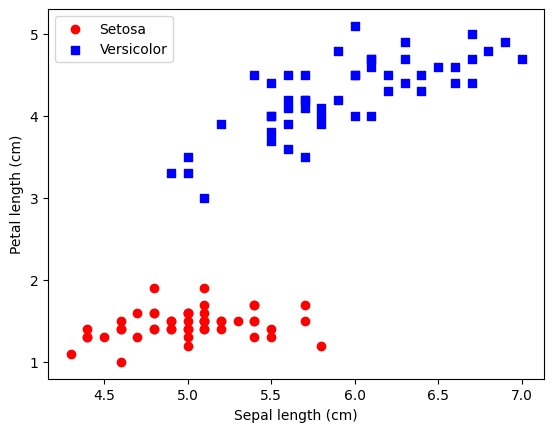

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
from sklearn.datasets import load_iris

# Use the bundled Iris data so Run all needs no external download.
iris = load_iris()
df = pd.DataFrame(iris.data)
df[4] = ['Iris-' + iris.target_names[t] for t in iris.target] # dataframe

# print(df.tail()) # just to ensure that the data was loaded correctly

y = df.iloc[0:100, 4].values # creates a np array (.values) from the species labels (4 == 5th column == species) of the first 100 rows
y = np.where(y == 'Iris-setosa', 0, 1) # 0 if setosa, 1 if versicolor (first 100 rows only have those two species)

X = df.iloc[0:100, [0, 2]].values # 100 x 2 matrix that extracts two features: sepal length (0) and petal length (2)

# Plot the two iris classes in the 100 x 2 matrix to visualize how separable they are before fitting a perceptron
# It's important that it's roughly linearly separable, which is when a perceptron would be a good choice

plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label = 'Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label = 'Versicolor')

# Note that the x-axis here would be sepal length (because it's in column 0) and y-axis would be petal length (column 1)
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.legend(loc='upper left')
plt.show()


- Seems like a linear decision boundary is possible, which means that a perceptron can classify this dataset perfectly.
- A perceptron would be an example of a **linear classifier**

### Personal Notes
- I shipped UI improvements to the [reader](https://github.com/jooonkim/reader) project. Rick Rubin was right - ship improvements to the product by focusing on what I want and need, and hope that there will be others who want the same.

### Questions I still have
- When implementing the code, I spent a lot of time trying to figure out why the author wrote each line the way that he did. It made me wonder how much of ML is printing out tails of datasets and plotting data to visualize it as a sanity check.

### Tomorrow's plan
- Finish implementing the perceptron to classify the Iris dataset.


## Perceptron convergence and decision boundaries

*Originally written 2025-11-27.*

In which we test whether the perceptron converged and visualize the decision boundaries for this 2-D dataset.


#### Perceptron implementation

Included from this repository’s shared implementation so this notebook runs independently in Colab.


In [4]:
import numpy as np

class Perceptron:
    """Classic perceptron classifier with NumPy tensors."""

    def __init__(self, eta: float = 0.01, n_iter: int = 20, random_state: int = 1):
        """
        Parameters
        ----------
        eta:
            Learning rate between 0 and 1.
        n_iter:
            Number of training epochs.
        random_state:
            Seed for deterministic weight initialization.
        """

        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X: np.ndarray, y: np.ndarray) -> "Perceptron":
        """Fit training data and record misclassification counts per epoch."""

        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.0)
        self.errors_: list[int] = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        return self

    def net_input(self, X: np.ndarray) -> np.ndarray:
        """Compute the linear combination of inputs and weights."""

        return np.dot(X, self.w_) + self.b_

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return the class label prediction for a given input."""

        return np.where(self.net_input(X) >= 0.0, 1, 0)


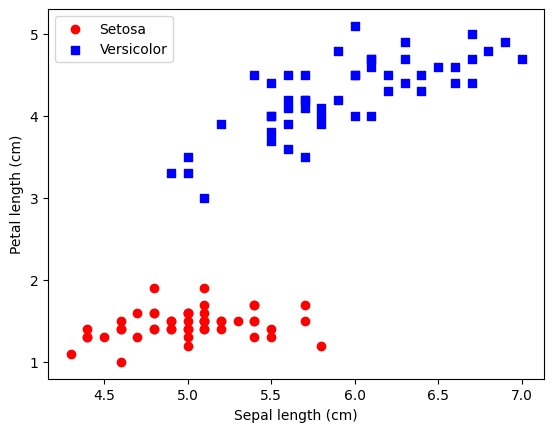

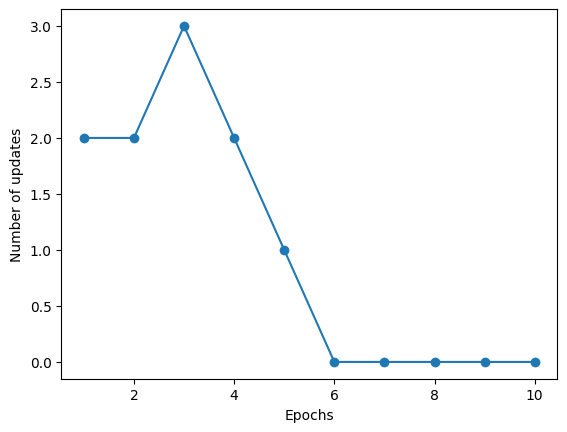

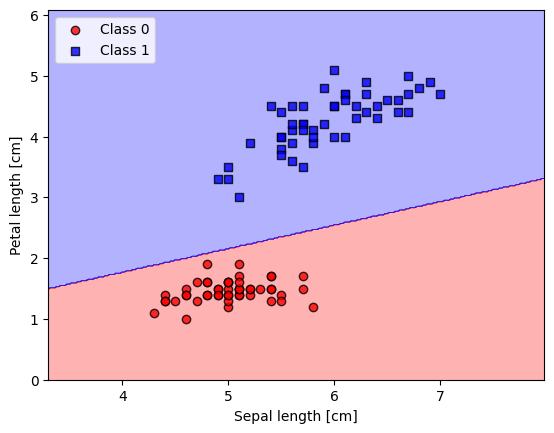

In [5]:
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
from sklearn.datasets import load_iris

# Use the bundled Iris data so Run all needs no external download.
iris = load_iris()
df = pd.DataFrame(iris.data)
df[4] = ['Iris-' + iris.target_names[t] for t in iris.target] # dataframe

# print(df.tail()) # just to ensure that the data was loaded correctly

# Goal here is to restrict the task to a binary classification problem
y = df.iloc[0:100, 4].values # creates a np array (.values) from the species labels (4 == 5th column == species) of the first 100 rows
y = np.where(y == 'Iris-setosa', 0, 1) # 0 if setosa, 1 if versicolor (first 100 rows only have those two species)

# Goal here is to extract two fairly separable features from the same 100 rows of y
X = df.iloc[0:100, [0, 2]].values # 100 x 2 matrix that extracts two features: sepal length (0) and petal length (2)

# Plot the two iris classes in the 100 x 2 matrix to visualize how separable they are before fitting a perceptron
# It's important that it's roughly linearly separable, which is when a perceptron would be a good choice

plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label = 'Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='s', label = 'Versicolor')

# Note that the x-axis here would be sepal length (because it's in column 0) and y-axis would be petal length (column 1)
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')
plt.legend(loc='upper left')
plt.show()

ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X,y) # train Perceptron on the Iris data subset

# Explore how the perceptron's training errors evolve over epochs.
# range(1, len(ppn.errors_) + 1) just creates the epoch numbers (x-axis)
plt.plot(range(1, len(ppn.errors_) + 1), ppn.errors_, marker='o') # draws a point for each training epoch
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.show() # Converges after 6th epoch

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')


plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')

plt.show()


> **Reusable code**
>
> This chunk pulls the `Perceptron` class from `code/ml_utils/perceptron.py`. Keeping reusable models in `code/` lets Quarto posts stay lean while GitHub readers can browse the source directly.
### Personal Notes
- There are two ways to run Python files:
    - `python script.py` runs the file directly.
    - `python -m package.module` runs it as part of a package (which makes package-style imports work).
- Think of your project as a bookshelf full of Python packages. When you run `python script.py`, you’re saying “open this file by its path.” Python doesn’t automatically know where that file sits on the shelf, so package-style imports may fail.
    - When you run `python -m ml_utils.plot_decision_regions`, you’re saying “look on the shelf for the `ml_utils` package, take the `plot_decision_regions` module out, and run it.” Because Python finds the module through the package, it automatically knows about `ml_utils` and any sibling modules. That’s why relative or absolute imports inside the module work—they’re being run “inside” the package instead of as a standalone file.
- A good setup: keep experimental scripts in an `experiments/` folder and run them with `python -m experiments.some_script` from the project root. That way they can import things from `ml_utils` without extra tricks.

> **Python tips**
>
> - A module is just a single `.py` file. For example, `perceptron.py` or `plot_decision_regions.py` each define functions/classes and can be imported with their filename (minus `.py`).
> - A package is a folder that contains modules (and usually an `__init__.py` file). It lets Python treat the folder as a single namespace so you can import things like `ml_utils.perceptron`.
> - The package provides structure and a shared namespace; the modules are the individual files inside it. When you run `python -m ml_utils.plot_decision_regions`, you’re telling Python to execute the `plot_decision_regions` module as part of the `ml_utils` package, so it knows how to resolve imports like from `ml_utils.perceptron import Perceptron`.
### Questions I still have
- Need to resist the urge to brush up on Python basics in a 101 bottom-up style.

### Tomorrow's plan
- I asked GPT-5.1 Codex to analyze my notes thus far and outline a path for what's to come:
    - Finish the perceptron loop: add dataset splits (train/test or cross-validation), compute accuracy/confusion matrices, and document failure cases when classes aren’t separable. This turns the current script into a minimal experiment you can evaluate.
    - Feature scaling & preprocessing: implement standardization pipelines to see how learning rate, convergence, and decision boundaries change, especially before moving beyond Iris.
    - Logistic regression & soft margins: move from perceptron to logistic regression or linear SVMs to understand probabilistic outputs, loss functions, and regularization—natural evolutions of your current model.
    - Multi-class strategies: prototype OvA or OvO wrappers around your perceptron/logistic models to reinforce how binary learners extend to multi-class tasks.
    - Experiment tracking: start logging hyperparameters, metrics, and plots (even in your daily notes) so you build the habit of reproducible ML experiments.
    - Deepen EDA intuition: answer your own question by comparing outcomes with and without exploratory plots—note when simple visuals caught issues early versus when they weren’t needed.


## Adaline and linear activation

*Originally written 2025-11-28.*

Adaline: another single-layer neural network

- **Adaline**: **Ada**ptive **Li**near **Ne**uron. Also known as the **Widrow-Hoff rule**: Published by Bernard Widrow and Tedd Hoff a few years after Rosenblatt's perceptron algorithm as an improvement.
- The Adaline algorithm is important because it introduces the importance of defining and minimizing **continuous loss functions**.
    - This lays the groundwork for other ML classification algorithms such as **logistic regression**, **support vector machines**, **multilayer neural networks**, etc.

Comparison with Perceptron
- Perceptron learning tweaks the weights when the predicted class (the net input and how it compares to the threshold) disagrees with the label. Each update uses `eta * (target - predict(x))` and it counts the errors per epoch.
- Consider the following loop from `Perceptron.fit()`:


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
for _ in range(self.n_iter):
    errors = 0
    for xi, target in zip(X, y):
        update = self.eta * (target - self.predict(xi))
        self.w_ += update * xi
        self.b_ += update
        errors += int(update != 0.0)
    self.errors_.append(errors)
return self
```


Adaline uses **Gradient Descent** to differentiate from Perceptron in 2 important ways:

- **Linear activation**: No more thresholding the net input. Instead, Adaline keeps the raw value `net_input = wx + b` and compares that to the true **continuous** target
- **Cost function and update**: Adaline minimizes the **sum of squared errors (SSE)** between `net_input` and `target`. 
    - Gradient of SSE w.r.t. weights: `(target - net_input) * x`
    - Weight update for weights & bias: `w += eta * (target - net_input) * x`

> **Why is the actual difference important?**
>
> The gradient using the actual difference is important because the updates become *smoother and differentiable*. This allows you to apply *batch or stochastic gradient descent*.
- Pseudocode for per-sample gradient descent loop:
    - Compute `net_input` for each sample
    - Calculate the error which is `target - net_input`
    - Determine the direction and magnitude to update the weights by multiplying that error by the input vector `x` and learning rate `eta`
    - Aggregate SSE per epoch to monitor whether it is converging

> **Why is this better than Perceptron?**
>
> Adaline relies on a continuous error surface, which allows it to converge when a Perceptron might oscillate


### Personal Notes
- This is the first time I've seen the mathematical intuition emerge as extremely important.
- It's hard to get back into ML studying. I'm trying to keep the big picture in mind of the "why" behind the learning.
- It's extremely motivating to listen to how [Gabriel Petersson](https://www.youtube.com/watch?v=vq5WhoPCWQ8) thinks about empowering yourself to learn using AI - getting down to the bottom of things and truly understanding vs. vibecoding.

### Questions I still have
- Why is Adaline a single layer neural network? I'm assuming it's because there's one "decision" that the algorithm makes before it corrects itself per epoch. This is consistent with what I'd expect given the videos I've seen of MNNs in action. Would love to understand whether this is correct.

### Tomorrow's plan
- I need to study up on [Gradient Descent](https://www.youtube.com/watch?v=sDv4f4s2SB8) to truly understand Adaline. I will watch [3Blue1Brown's video](https://www.youtube.com/watch?v=IHZwWFHWa-w) as well.


## Understanding gradient descent

*Originally written 2025-11-29.*

Gradient Descent, or how machines learn

- When measuring how "costly" a wrong prediction is / how "accurate" a training example was, you can use a **loss function**.
- One example of a loss function is the **Sum of Squared Errors (SSE)**. Formally defined as:

$SSE = \sum\limits_{i} (y_i - \hat{y}_i)^2$

> **What's great about SSE?**
>
> - It is said to be appropriate when modeling regression with Gaussian noise.
> - It is not appropriate for classification or distributions with outliers (perhaps because it penalizes large errors heavily?).
- Recall that **Weights** $w$ represent how strongly each input dimension influences the neuron, and the **Bias** $b$ shifts the activation threshold and acts as an offset.
    - [3Blue1Brown](https://www.youtube.com/watch?v=IHZwWFHWa-w) says: Neurons are connected to the neurons in the previous layer. The weights are the strength of those connections, and for ReLU-like activations, the bias affects when the neuron is active/inactive.
    - **ReLU** here refers to a Rectified Linear Unit, and it can be defined as $ReLU(a) = max(0, a)$. Basically, the sigmoid was a slow learner and hard to train, and the ReLU made things easier by making a neuron "active" ($a$) or "inactive" ($0$).
- A network "learns" by adjusting the parameters $W$ and $b$ to minimize a cost function / loss function. 

> **W vs. w**
>
> $W$ and $w$ mean different things in neural networks.
> 
> $W$: A weight matrix for an entire layer. If a layer has $n_{in}$ inputs and $m_{out}$ neurons, then $W \in R^{n_{in} \times m_{out}}$. Each row is the weight vector of *one neuron*, and $z = Wx + b$ is the equivalent of doing many individual dot products at once.
> 
> $w$: A weight vector for a single neuron.
> 
> $w = \begin{bmatrix}
> w_1 \\
> w_2 \\
> \vdots \\
> w_n
> \end{bmatrix}$
Formally, **Gradient Descent** is the algorithm used to minimize a loss function $J(\theta)$ by iteratively updating parameters in the direction that reduces the loss:

$\theta := \theta - \eta \nabla_{\theta} J(\theta)$

- What is great about Gradient Descent is that the network can minimize this loss function by converging towards a local minimum, even when the derivative of the minimum is not 0.
- Gradient Descent, by design, can take big "steps" towards the minimum when it determines that it is far away, and smaller steps when it determines that it is closer.
- Think of a "step" as the derivative of the sum of squared residuals with respect to a certain parameter, multiplied by a learning rate
- Gradient Descent stops taking steps when the "step size" is very close to 0 or if it is forced to give up (i.e., it surpasses the maximum number of steps)

> **Why is it called Gradient Descent?**
>
> - A **Gradient** is two or more derivatives of the same function
> - A **Gradient** gives the direction of steepest increase (from Multivariable Calculus)
> - We use this Gradient to descend in the direction of $-\nabla J(\theta)$ to reach the lowest point of the loss function.
Gradient Descent in plain English:

1. Find the derivative of the Loss Function for each parameter in it. (i.e., take the Gradient of the Loss Function).
2. Pick random values for the parameters, and plug them into the Gradient.
3. Calculate the step sizes, where step size == slope * learning rate
4. Calculate the new parameters, where new parameter = old parameter - step size
5. Repeat 3 - 4 until the step size is very small or you reach a max number of steps.


### Personal Notes
- Gabriel Petersson said to "decide between diffusion or LLMs" when starting out with ML. It seems that modern ML has two giant "starting domains" that give you maximum learning per unit of effort. In these worlds:
    - the abstractions are clean
    - the tooling is mature
    - the concepts are foundational
    - the project ideas are endless
    - the market impact is real
    - the architecture teaches you almost everything else downstream
- It is interesting because you can look at this as:
    - **Diffusion** = generative modeling in continuous noise spaces (images, for example, are made of continuous values).
    - **LLMs** = generative modeling in discrete token spaces (language is discrete and is generated by tokens, or integer indices in a finite vocabulary).
- The final frontier for LLMs appears to be domain expertise and writing great evals. It seems like that's what's missing with today's frontier models - how well does it replicate something a domain expert would consider to be good? That is the competitive advantage. More to come here (would like to experiment with interviewing domain experts and writing evals with them).

### Questions I still have
- To answer a question from yesterday, it does seem like MNNs are a version of the SNN where there is a $wx + b$ weight & bias calculation per layer, and then you do it again and again.

### Tomorrow's plan
- I need to complete my understanding of Gradient Descent. I developed an intuition for it, but it is still basic.


## Gradient descent and Adaline

*Originally written 2025-12-08.*

Gradient Descent + Returning to Adaline

#### Gradient Descent in plain English:

1. Find the derivative of the Loss Function for each parameter in it. (i.e., take the Gradient of the Loss Function).
2. Pick random values for the parameters, and plug them into the Gradient.
3. Calculate the step sizes, where step size = learning rate * Gradient
4. Calculate the new parameters, where new parameter = old parameter - step size (the minus sign moves you downhill)
5. Repeat 3 - 4 until the step size is very small or you reach a max number of steps.

- For a single parameter, the Gradient is the slope of the loss with respect to that parameter (slope == Gradient).
- When you do this over multiple weights, Gradient Descent also helps you understand which weights and connections matter *more* in a given step
- Gradient Descent encodes the relative importance of each weight
- Therefore, Gradient Descent is learning defined by minimizing the output of a loss function.

#### Returning to Adaline, which makes full use of the loss function being differentiable...

Reminder from 11/28 Notes:

- Adaline uses **Gradient Descent** to differentiate from Perceptron in 2 important ways:
    - **Linear activation**: No more thresholding the net input. Instead, Adaline keeps the raw value `net_input = wx + b` and compares that to the true **continuous** target
    - **Cost function and update**: Adaline minimizes the **sum of squared errors (SSE)** between `net_input` and `target`. 
        - Gradient of SSE w.r.t. weights: `(target - net_input) * x`
        - Weight update for weights & bias: `w += eta * (target - net_input) * x`

> **Why is the actual difference important?**
>
> The gradient using the actual difference is important because the updates become *smoother and differentiable*. This allows you to apply *batch or stochastic gradient descent*.
- Pseudocode for per-sample gradient descent loop:
    - Compute `net_input` for each sample
    - Calculate the error which is `target - net_input`
    - Determine the direction and magnitude to update the weights by multiplying that error by the input vector `x` and learning rate `eta`
    - Aggregate SSE per epoch to monitor whether it is converging

> **Why is this better than Perceptron?**
>
> Adaline relies on a continuous error surface, which allows it to converge when a Perceptron might oscillate


Implementation (annotation comes tomorrow)


In [6]:
from __future__ import annotations
from mimetypes import init

import numpy as np

__all__ = ["AdalineGD"]

class AdalineGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    --------------

    eta: float. 
        This is the learning rate (between 0.0 and 1.0)
    n_iter: int
        Passes over the training dataset
    random_state: int
        Random number generator seed for random weight generalization
    
    Attributes
    ---------------
    w_: 1D-Array
        Weights after fitting
    b_: Scalar
        Bias after fitting
    losses_: list
        Mean Squared Error loss function values in each epoch
    """
    def __init__(self, eta=0.01, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X
    
    def predict(self, X): 
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        -----------
        X: array-like, shape = [m_examples, n_features]
            Training vectors
            m_examples: # of examples
            n_features: # of features
        
        y: array-like, shape = [m_examples]
            Target values
        
        Returns
        -----------
        self: object
        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter): # for each epoch
            net_input = self.net_input(X) 
            output = self.activation(net_input)
            errors = (y - output)
            """This step is important!
            We are calculating the gradient based on the whole training set,
            not just evaluating each individual training example (as in the perceptron).
            """
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean() 
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self


### Personal Notes
- 3Blue1Brown brought up an interesting point in his Neural Networks intro video that representation in terms of linear algebra is useful because of the libraries that have already been built and optimized for fast performance (`numpy`). Might seem obvious, but cool.
- 3Blue1Brown also mentioned that Gradient Descent is a good reason why the neural network calculations (the neuron calculations involving weights & biases) should be continuous and not discrete values.
- Remember that the neural network was never told what patterns to look for... Gradient Descent can often figure it out. It's crazy how much you can do just by minimizing loss across the training data.

### Questions I still have
- It's not quite clear how the errors array contains partial derivatives?
- I am still not 100% confident with my file structure (where I save my .py implementations and how I run it within my Quarto notes)

### Tomorrow's plan
- Go through the Adaline implementation with GPT-5.1 Codex, line by line, until I can fully explain what each step is doing.


## Adaline implementation, line by line

*Originally written 2025-12-10.*

Adaline implementation


In [7]:
import numpy as np

class AdalineGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    --------------

    eta: float. 
        This is the learning rate (between 0.0 and 1.0)
    n_iter: int
        Passes over the training dataset
    random_state: int
        Random number generator seed for random weight generalization
    
    Attributes
    ---------------
    w_: 1D-Array
        Weights after fitting
    b_: Scalar
        Bias after fitting
    losses_: list
        Mean Squared Error loss function values in each epoch
    """
    def __init__(self, eta=0.01, n_iter = 50, random_state = 1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def net_input(self, X):
        """Calculate net input
        
        Think of this as the linear combination of features and weights + bias
        This helps get the neuron's "raw score"
        """
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation
        
        This is just the identity."""
        return X
    
    def predict(self, X): 
        """Return class label after unit step
        
        Binary class label of 1 when the activation >= 0.5, else 0
        """
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        -----------
        X: array-like, shape = [m_examples, n_features]
            Training vectors
            m_examples: # of examples
            n_features: # of features
        
        y: array-like, shape = [m_examples]
            Target values
        
        Returns
        -----------
        self: object
        """

        # Initialize the RNG, weights w_ with small random values, bias b_ to zero, losses_ empty
        rgen = np.random.RandomState(self.random_state)
        # This starts weights as tiny random numbers
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1]) 
        # This starts the bias at zero
        self.b_ = np.float64(0.)
        # This prepares a list to record training error at each pass
        self.losses_ = []

        for i in range(self.n_iter): # for each epoch
            # Given whatever is w_ and b_, we're computing the raw score for each example
            net_input = self.net_input(X) 
            # Activation is the identity (no "squashing" yet)
            output = self.activation(net_input)
            # How far off are we from the desired targets? 
            # Positive if too low, negative if too high
            errors = (y - output)
            
            """Weight update. 
            
            This step is important!
            We are calculating the gradient based on the whole training set,
            not just evaluating each individual training example (as in the perceptron).
            This makes the learning "smoother" - less aberrations because of individual examples.

            This is called "Batch Gradient Descent." 
            
            Think of the model as making guesses with two kinds of knobs:
            w_: one knob per input feature (like volume sliders for each input).
            b_: one extra knob that shifts everything up or down (like a master volume).

            Weight update (the "averaged nudge"):

            Recall that error = (y - (X * w + b))
            Multiplying by * 2.0 is because of the Chain Rule
            The loss is error^2, so the derivative is 2 * error * derivative of error
            Derivative of (X * w + b) w.r.t. w is X.
            Multiply X.T * error to aggregate per feature across all samples

            X has rows of training examples, columns of features
            errors is rows of how wrong we were per example
            X.T is the transpose of X so that each feature lines up with the 
                errors across example
            X.T.dot(errors) is the dot product that combines every feature with 
                its errors. 
            X is (n_samples, n_features); errors is (n_samples,). 
            Flipping X gives X.T as (n_features, n_samples).
            Dotting (n_features, n_samples) with (n_samples,) yields (n_features,):
                a separate summed value for each feature.
            
            Recall that the loss is the mean squared error
            Therefore, we need to divide by N (# of examples) so the 
                summed gradient becomes an average
            / X.shape[0] means “take the average over all examples” so we dont 
                overreact to any single case.

            Bias update: nudge the bias by the avg error
            """
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            # Compute Mean Squared Error
            loss = (errors**2).mean()
            # Track loss history so we can see learning progress
            self.losses_.append(loss)
        return self


### Personal Notes
- I think I understand the implementation line by line. This [tweet](https://x.com/GabrielPeterss4/status/1861924146336448817) by GabrielPeterss4 helped. It's worth reviewing again and again.

### Questions I still have
- Need to be able to implement this from scratch. I wonder if I'm missing the forest for the trees here, but I do think it's important to really understand Gradient Descent forwards and backwards.

### Tomorrow's plan


## Classification with scikit-learn

*Originally written 2025-12-11.*

Introduction to Classification (Using scikit-learn)

- Given the "no free lunch theorem," it is always recommended to try a handful of different learning algorithms to choose the best for a particular problem.
- Factors include:
    - The amount of training examples or features
    - The amount of noise in the dataset
    - Whether the classes are linearly separable

#### 5 main steps involved in training a supervised ML algorithm
1. Selecting features + collecting (labeled) training examples.
2. Choosing a performance metric.
3. Choosing a learning algorithm + training a model.
4. Evaluating the performance based on the performance metric.
5. Changing the settings of the algorithm + tuning the model. (Adjusting hyperparameters like learning rate, # of epochs, etc.)


### Personal Notes
### Questions I still have
### Tomorrow's plan


## Python essentials for ML

*Originally written 2025-12-13.*

Brief Interlude on Python

- For debugging/testing, using `python -i` as in `python3 -i helloworld.py` is helpful because it runs the program and then enters the interactive shell afterwards.
    - This is helpful when I define a function and then experiment with this defined function
    - Also helpful when I use exception handling
- Use `snake_case` for multiple word variable names instead of camelCase
    - Prefer lowercase
- Use leading `_` for "private" or internal names. This is helpful because it reduces accidental use outside a module/class. Not real access control.
    - E.g., `def _internal_helper`
    - `from module import *` will skip underscored names
- You can add placeholders for statements to be added later with a `pass` such as below:


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
if name in namelist:
    # not evaluated yet
    pass
else:
    # statements
```


- You have to close files after opening and using them, like as follows:


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
f = open('foo.txt','r')
# Use f
f.close()
```


- You can achieve the same purpose using `with` and it automatically closes:


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
with open('foo.txt', 'r') as f:
    # automatically closes afterwards

    # for line-by-line reads
    for line in f:
        # Process the line
    
    # for reading the entire file into a strong
    data = f.read()

    # for writing into a file
    f.write('some text\n')
```


#### Exception Handling
- **Exception Handling**: This is how Python deals with things going wrong. Errors are "exceptions"
- Wrap risky code in `try` blocks
- With proper exception handling, if an error/exception occurs, control jumps to an `except` block. 
- Without an `except` block, any runtime error can crash our script. 
- With an `except` block:
    - Long-running programs stay alive after isolated failures
    - Friendly error messages instead of tracebacks
    - Differentiate between expected issues (aka user error) and bugs
- Importantly, the name must match the type of error you're trying to catch (e.g., `ValueError`, `ZeroDivisionError`)
- Exceptions have associated values that can be passed to variables (e.g., `except ValueError as e`)
- Also, `finally` can be used for cleanup and for code that *must* run whether or not an exception occurs
    - Also useful for managing resources (esp. files)


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
try:
    result = divide(num, denom)
except ZeroDivisionError:
    print("Can't divide by zero—please try again.")
except ValueError as e: # can catch different kinds of exceptions, and prints the associated value
    print("Value error—please try again.", e)
else:
    print("Result:", result)
finally:
    cleanup_resources()
```


- Here's something I wrote, which also includes an `f-string` that allows me to drop values into the string with {...}


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
def portfolio_cost(file_name):
    total_cost = 0.0

    with open(file_name, 'r') as f:
        for line in f:
            fields = line.split()
            try:
                number_shares = float(fields[1])
                purchase_price = float(fields[2])
                total_cost += number_shares * purchase_price
            except ValueError as e:
                print(f"Couldn't parse: {line.strip()}")
                print("Reason: ", e)
    return total_cost
```


#### Objects
- All of the basic data types (strings, integers, lists, etc.) are Objects, therefore they involve "methods" to carry out operations
- You make your own Objects as follows (with their own methods):


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
class Player:
    def __init__(self, name, age):
        self.name = name
        self.age = age
        self.health = 100
    
    def move(self, points):
        self.health -= points
```


- `__init__` method initializes a new instance and is important for storing data attributes
- By convention, the method is called on `self` and `self` is defined as the first argument
    - The actual name is unimportant. Just know that the object is always passed as the first argument.
    - Just conventional Python style to call it `self`
- `import module as m` imports a module (a namespace) that are the (global) variables and functions defined in `module.py`
    - Everything defined with global scope can be called as `m.method()`
    - `from module import function` allows you to import certain functions from a module and put them into local scope. No need to use the module prefix `module.function()`
    - `from module import *` allows you to import all functions. Don't use this often in practice because it impacts readability.

#### Data Structures
- Three options for data structures:
    - tuples
    - dictionaries
    - classes (user-defined)
- **Tuples** are a collection of values (e.g., `s = (GOOG, 10, 300.20)`).
    - Can be used like an array (`quantity = s[1]`)
    - Can be unpacked into separate variables (`name, quantity, price = s`).
    - Immutable (`s[1] = 1` throws a `TypeError`)
- **Dictionaries** are an unordered collection of key-value pairs (e.g., s = {'name': GOOG, ...})
    - Use the key values to access (`google_price = s[price]`)
    - Can be modified (`s[price] = 320.20`)
- **User-Defined Classes** as defined above provide the nice clean syntax we know and love (e.g., `s.name`). 
- Some "advanced" variants that are worth knowing:
    - **Slots**: Saves memory
    - **Dataclasses**: Reduces coding
    - **Named Tuples**: Immutability/Tuple behavior
- Why are **Slots** so great?
    - `__slots__` are useful as a *performance optimization* because Python typically creates a `__dict__` for the attributes of every instance of an object.
    - These per-instance dictionaries allow you to add arbitary attributes at runtime, but have high memory overhead.
    - In exchange for enumerating the attributes your instances will ever need in advance, a fixed slot layout saves the memory overhead of per-instance dictionaries.
    - This is especially useful when you have many objects.


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
class Player:
    __slots__('name', 'age', 'health')
    def __init__(self, name, age):
        self.name = name
        self.age = age
        self.health = 100
```


- Why are **Dataclasses** so great?
    - It's just easier... it helps make boilerplate-free classes.
    - Python auto-generates helpers like `__init__`
    - You do need to annotate the types (even if it's just `Any`)


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
from dataclasses import dataclass

@dataclass
class Player:
    name: str
    age: int
    health: int
```


- Why are **Named Tuples** so great?
    - *Dataclasses with guaranteed immutability.*
    - The most important feature is **Immutability**, which allows you to safely use them as dict keys
    - Other features for tuples (indexing, etc.) are useful here too.


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
import typing

class Player(typing.NamedTuple):
    name: str
    age: int
    health: int
```


### Personal Notes
- I'm feeling a lot of anxiety to start "doing" rather than just consuming information, step by step, from a textbook. I've been coding more aggressively as a result.
- A reminder to myself on how learning via a textbook should feel:
    - like pieces of a puzzle retroactively coming together
    - like previous experiences making far more sense in context
    - like seeing in the light what I once grasped around for in the dark
- I'm trying to avoid tutorial hell by building until I get stuck, and grasping around for the necessary context as I go.

### Questions I still have
### Tomorrow's plan


## Planning a customer churn project

*Originally written 2025-12-14.*

Project-Based Learning (Sabbatical Day 1)

#### Data Preparation
- Before any task, it's important to prepare the data by understanding the columns, understand the target definition, and define safe and consistent `train/val/test` splits.
- Questions you should be asking: What columns are categorical vs. numeric? What are the names of any important columns? Are there any missing values that need imputation?
- Also great to run `df.head()` and `df.info()` and histograms/bar charts.
- In our case, `df['Churn'].value_counts()` is great to understand the raw counts of each label. How many churners are there? How rare is it?
    - This can also help stratify your train/val/test splits so each set preserves the ratio (no accidental “easy” test set).

- We're using a helper function for `load_data`. Why? *It's important to be consistent about preprocessing.*
    - Stratifying into train/val/test is consistent for each experiment. 
    - You can document the **random seed**, i.e., the number provided to a random number generator so that the rows are shuffled the same way.
- The goal is to be consistent about shuffling and splitting the data!


**Illustrative snippet — not a runnable cell.** This example was marked non-executable in the original notes.

```python
"""Data loading utilities: fetch OpenML dataset and split into train/val/test."""
from typing import Tuple
from sklearn.datasets import fetch_openml

def load_data(dataset_id: str, test_size: float = 0.2, val_size: float = 0.1, random_state: int = 42) -> Tuple[object, object, object, object]:
    """Fetch dataset via OpenML, then return (X_train, X_val, X_test, y variants).

    Placeholder: use sklearn.datasets.fetch_openml, then train/val/test split.
    Over-explain steps when implemented so future readers learn why each choice matters.
    """
    # Download the raw table from OpenML to understand the dataset
    churn_data = fetch_openml(data_id="45568")
```


#### Python Notes
- Putting reusable logic code under `src/` (short for "source") is conventional for keeping the project tidy
- The reusable functions, models, training data is all within `src/` and reports, implementation, etc. are separate.
- Python also treats `src/` as the source root, so relative imports stay clean.

### Personal Notes
- Today is Day 1 of my one week sabbatical, a sprint to cover as much ML mastery as possible by the end of the week.
- To approach this from a project-based learning perspective, I chose to create the following [project](https://github.com/jooonkim/churn-ml)
- Need to understand **trees, kNN, ensembles, SVMs/kernels, theory/VC, randomized optimization, information theory, Bayesian learning, clustering/EM, ICA/manifold learning, RL**.
- Therefore, I chose a project that is not just following along with Andrej Karpathy's "Zero to Hero" and more of a "classical" ML problem.
    - I will do an LLM-focused project as a 2-day "attention from scratch" mini-lab at the end.
    - LLM-focused project: Great for creating a deep intuition for gradients, cross-entropy, batching, etc.
- I'll also get in the habit of writing reports. For each experiment, write a 2–3 sentence “hypothesis → result → takeaway”.

#### Project Goals
- Compare multiple supervised algorithms: decision trees, kNN, ensembles, SVMs/kernels, neural nets. 
- Do optimization & uncertainty in a practical way: randomized search / hyperparameter tuning, thinking about inductive bias + generalization, and even “deconstructing AdamW” concepts via controlled experiments. 
- Do unsupervised: clustering + EM/GMM intuition, feature selection/transformation (ICA, manifold learning). 
- Use the exact tooling expectations: sklearn pipelines/CV/calibration + PyTorch MLP.

#### Project scope
- I chose a **tabular churn analysis** task: using ML models to predict customer churn using structured datasets.
- Using the `telco-customer-churn` [dataset](https://www.openml.org/search?type=data&status=active&id=45568).

###### Deliverables
1) **sklearn baselines (fast, high learning ROI)**: Run and compare:
- Logistic Regression (strong baseline)
- Decision Tree
- Random Forest / Gradient Boosting
- SVM (RBF or linear)
- kNN
All using the same Pipeline(preprocess → model) and Stratified CV.

Metrics to report

- ROC-AUC + PR-AUC (PR-AUC is important if churn is imbalanced)
- F1 (macro or positive-class)
- Confusion matrix
- Calibration curve (optional but great)

2) **PyTorch model (beginner-friendly)**: Train a small MLP for churn:
- Option A (simplest): reuse the sklearn preprocessing output (one-hot + scaled) and feed that into an MLP.
- Option B (more “deep learning”): learn embeddings for categorical columns + concat with scaled numeric features.
Either way, you’ll learn the “real” deep learning loop: batching, loss, optimizer, early stopping.

#### Summary: Scope and Learning Plan
- **Dataset:** Telco Customer Churn (`openml id=45568`), tabular, binary target.
- **Primary goal:** Learn ML by comparing diverse models, not just finishing quickly.
- **Baselines (sklearn, all via Pipeline + Stratified CV):** Logistic Regression, Decision Tree, Random Forest/Gradient Boosting, SVM (RBF or linear), kNN. Report ROC-AUC, PR-AUC, F1 (positive class), confusion matrix, and optionally calibration curves.
- **Hyperparameter tuning:** Small, educational `RandomizedSearchCV` grids to see variance and inductive bias effects. Log mean/std CV scores and settings.
- **PyTorch MLP:** Start with preprocessed tabular features (one-hot + scaled). Train a small MLP with batching, optimizer choice (SGD vs Adam/AdamW), early stopping. Later, try embeddings for categorical features.
- **Unsupervised explorations:** Clustering (k-means, GMM/EM) to inspect churn by cluster; dimensionality reductions (PCA/ICA; t-SNE/UMAP for visualization); feature importance/selection (tree/permutation-based).
- **Reporting habit:** For each experiment, write a short entry in `report/report.md` (hypothesis → setup → metrics → takeaway) and save plots to `report/figures/` (ROC/PR curves, confusion matrices, calibration, learning curves).
- **Data discipline:** Use consistent train/val/test splits (stratified), avoid leakage, and keep preprocessing inside the pipeline so CV/test use the exact same transforms.


## Bias, variance, and regularization

*Originally written 2025-12-20.*

Bias Variance & Regularization

The five-step process that the authors propose in the paper [Prediction of Advertiser Churn for Google AdWords](https://research.google/pubs/prediction-of-advertiser-churn-for-google-adwords/):

1. Select samples for analysis
2. Define churn and select features (potential explanatory variables)
3. Process data: transform features and impute missing values
    - The goal of the third step is to generate more discriminating/relevant features to predict churn. This can be done via linear or non-linear transformations. Some examples are PCA, LDA, data preprocessing. 
4. Build predictive models
5. Evaluate trained models

![Screenshot showing the model workflow](https://raw.githubusercontent.com/jooonkim/ml/main/posts/daily/2025-12-20/workflows.png)

#### Bias Variance

- **Underfitting: High Bias**
- **Overfitting: High Variance**
- Think of **bias** in ML as a algorithm's preconception of the shape of the model.
- Think of **variance** in ML as how much the model might change based on new data. For a regression model, if it's overfit on your dataset, then new data will lead to a wildly different model.
- Workflow: Fit an algorithm that's "quick & dirty" then understand whether it's high bias or high variance and improve it.
- Regression models & Classification models are both subject to bias variance.

#### Regularization

The **Linear Regression Objective Function** ("Least Squares Cost Function") is:

$\min_{\theta}\; \frac{1}{2}\sum_{i=1}^{m}\left\|y^{(i)}-\theta^{T}x^{(i)}\right\|^{2}$

- $\min_{\theta}$: Choose a $\theta$ that minimizes the total squared residual magnitude across all training examples.
- $\frac{1}{2}$ doesn't change the minimizer, and is included for algebraic convenience (to get rid of the factor of 2 when differentiating a squared term)
- $\sum_{i=1}^{m}$ is the sum across $m$ training examples
- With linear regression, the **predictor** $\hat{y}^{(i)}$ is the dot product $\theta^{T}x^{(i)}$. This is the guess of the model. It is **linear with the parameters** in that $\theta$ only appears to the first power. This is very important! Optimization becomes harder (you can use gradient descent for local minima) with non-linear parameters.
- If $y^{i} \in \mathbb{R}$ (a **scalar output**), then the **Euclidean norm** $\left\| \right\|$ is redundant (you can use $(...)$ instead). 
- But given that $y^{i} \in \mathbb{R}^{k}$ (a **vector output**), then you need the Euclidean norm.

To add **Regularization**, you add a **regularization term**:

$\min_{\theta}\; \frac{1}{2}\sum_{i=1}^{m}\left\|y^{(i)}-\theta^{T}x^{(i)}\right\|^{2} + \lambda\left\|\theta\right\|^{2}$

Sometimes you write multiply $\lambda$ by $\frac{1}{2}$ to make derivation easier:

$\min_{\theta}\; \frac{1}{2}\sum_{i=1}^{m}\left\|y^{(i)}-\theta^{T}x^{(i)}\right\|^{2} + \frac{\lambda}{2}\left\|\theta\right\|^{2}$

- The advantage of adding a small $\lambda$ (say, $\lambda = 1$) is that it penalizes $\theta$ from being too big. Therefore, *it makes it harder for the learning algorithm to overfit the data*.
- If $\lambda$ is too big (say, $\lambda = 1000$), however, you risk underfitting the data.


### Personal Notes
- Self-directed projects are hard to understand where to begin, so I read two papers for examples of Classification: [Prediction of Advertiser Churn for Google AdWords](https://research.google/pubs/prediction-of-advertiser-churn-for-google-adwords/) and [Building Airbnb Categories with ML and Human-in-the-Loop](https://medium.com/airbnb-engineering/building-airbnb-categories-with-ml-and-human-in-the-loop-e97988e70ebb).
- For the AdWords paper, I found it interesting that the definition of "customer churn" was not well-defined. 
- The challenge with top-down learning is that groping around in the dark can be incredibly demotivating. Watching the Stanford lectures felt like a breath of fresh air. I was also able to focus more effectively than just openly learning. Seems like the optimal balance is to have both.

- Used [Andrew Ng's lectures on data splits](https://www.youtube.com/watch?v=rjbkWSTjHzM&list=PLoROMvodv4rMiGQp3WXShtMGgzqpfVfbU&index=8) to understand how to split data for my project.
- Used [Chris Piech's lecture](https://www.youtube.com/watch?v=ILqZWvDWKEc) to understand Logistic Regression.

### Questions I still have
### Tomorrow's plan


## Linear regression and gradient descent

*Originally written 2025-12-21.*

Linear Regression, Batch & Stochastic Gradient Descent

#### Linear Regression Refresher

- Perhaps the simplest supervised learning algorithm
- In simple terms:

1. Training Set 
2. Generate Learning Algorithm
3. Generate $h$ (hypothesis) that takes an input and generates an output

$h$ is typically represented as:
$$
h(x) = \theta_{0} + \theta_{1}x_{1} + \theta_{2}x_{2}...
$$

or:

$$
h(x) = \sum_{i=0}^{n}\theta_{i}x_{i}$ where $x_{0} = 1
$$ 

(i.e., $x_{0}$ is a dummy feature)

If $\theta$ are "parameters" then the job of the learning algorithm is to choose great parameters.

> **Note**
>
> $(x^{(i)}, y^{(i)})$ is the $i$th training example for $x$ and $y$.
> 
> $(x^{(i)}_1, y^{(i)}_1)$ is the 1st feature of the $i$th training example for $x$ and $y$.
Now given that the goal is to choose $\theta$ such that $h(x)$ is close to $y$ for the training examples, the **cost function for linear regression** (also called the Mean Squared Error or Least Squares Cost) is:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2
$$

where:

- $J(\theta)$: the cost to minimize
- $m$: number of training examples
 - $h_\theta(x^{(i)})$: prediction using current parameters $\theta$ on input $x^{(i)}$
 - $y^{(i)}$: true value for the $i$th example

The $\frac{1}{2}$ keeps the derivative clean when the square is expanded, and the $\frac{1}{m}$ averages the summed errors so the scale stays consistent as more data is added.

This function measures how well our linear model with parameters $\theta$ fits the training data. The goal of learning is to find $\theta$ that minimizes $J(\theta)$.

#### Batch Gradient Descent

Gradient Descent has already been covered, but wanted to highlight that the axes are very important here.

![Gradient Descent](https://raw.githubusercontent.com/jooonkim/ml/main/posts/daily/2025-12-21/gradientdescent.png)

The algorithm is as follows:

$$
\theta_{j} := \theta_{j} - \alpha \frac{\partial}{\partial \theta_{j}} J(\theta)
$$

for each parameter $\theta_j$ (for $j = 0, 1, ..., n$):

Repeat until convergence:  
$$
\quad \theta_{j} := \theta_{j} - \alpha \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)x^{(i)}_j
$$

Where:  

- $\alpha$ is the learning rate  
- $J(\theta)$ is the cost function  
- $h_\theta(x^{(i)})$ is the model prediction for example $i$  
- $y^{(i)}$ is the true label for example $i$  

- Note that this updated, correct algorithm is a *sum* of the training examples. This is called **Batch Gradient Descent**. 
- Batch Gradient Descent processes all of the data in one batch.
- If the dataset is too large, the single step of gradient descent can become slow (you have to scan through $m$ examples).
- If you see the cost function $J(\theta)$ increasing rather than decreasing, that is a good sign that $\alpha$ the learning rate is too large.
- You "stop" Gradient Descent when you plot the cost function $J(\theta)$ and don't notice any changes

#### Stochastic Gradient Descent

- This solves the problem of progress being prohibitively slow with a large dataset with Batch Gradient Descent


## Logistic regression and the sigmoid function

*Originally written 2025-12-27.*

Logistic Regression

#### Logistic Regression


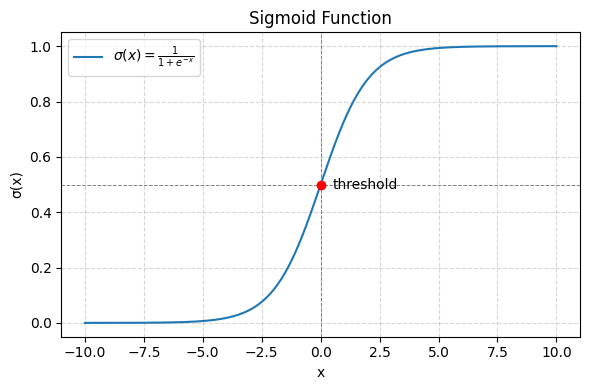

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 400)
y = sigmoid(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r'$\sigma(x) = \frac{1}{1 + e^{-x}}$')
plt.axvline(0, color='gray', lw=0.7, ls='--')
plt.axhline(0.5, color='gray', lw=0.7, ls='--')
plt.scatter([0], [0.5], color='red', zorder=5)
plt.text(0.5, 0.5, 'threshold', va='center')
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.title('Sigmoid Function')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


Consider the **sigmoid function**, which is popular within AI because it squashes $x$ to be a number between 0 and 1. 

$\sigma(x) = \frac{1}{1 + e^{-x}}$

Consider the **weighted sum** (aka dot product) which is:

$\theta^{T}x = \sum_{i=1}^{m}\theta_{i}x_{i}$

Therefore the **sigmoid function of the weighted sum** is:

$\sigma(\theta^{T}x) = \frac{1}{1 + e^{-\theta^{T}x}}$

- The "lightbulb idea" behind **logistic regression** is predicting $P(X | Y)$ directly (more rigorously than a **Naive Bayes Classifier**).
- Logistic regression predicts discrete (e.g., True vs. False) rather than continuous values. It fits a function resembling a sigmoid function to the data.
- Instead of least squares as a cost function, it uses **maximum likelihood**
